Total shape: (6653837, 27)
📊 Summary of Wage by Year


,count,mean,std,median
year,,,,
"2,009",55020,"66,170","68,539","63,586"
"2,010",265175,"71,291","62,781","65,220"
"2,011",304293,"79,215","62,664","70,000"
"2,012",318722,"80,944","56,504","71,436"
"2,013",374350,"82,034","42,741","72,300"
"2,014",444071,"83,002","36,568","73,012"
"2,015",185781,"80,239","33,023","71,178"
"2,016",76742,"94,629","36,921","85,093"
"2,017",523723,"91,738","38,444","82,000"


🏢 Summary of Wage by Top Employers


,count,mean,std,median
EMPLOYER_NAME_CLEAN,,,,
infosys,189873,"83,856","21,924","78,759"
tata consultancy services,141811,"85,125","30,646","81,870"
cognizant technology solutions us,127542,"93,857","26,290","91,270"
amazon com services,88236,"143,211","68,253","142,110"
microsoft,87800,"143,553","35,096","141,380"
ernst young u s llp,86846,"126,329","76,450","115,920"
deloitte consulting llp,83899,"105,073","50,755","97,000"
google,82148,"157,670","63,680","153,000"
wipro,62187,"76,902","30,680","74,501"


🌎 Summary by State


,count,mean,std,median
WORKSITE_STATE,,,,
CALIFORNIA,1262346,"126,086","82,313","119,327"
TEXAS,767131,"101,013","76,628","93,636"
NEW YORK,545709,"111,223","82,356","96,000"
NEW JERSEY,409555,"98,142","69,112","90,000"
ILLINOIS,329627,"95,625","75,693","85,000"
WASHINGTON,324970,"129,287","74,371","125,000"
MASSACHUSETTS,256647,"104,290","82,674","95,000"
GEORGIA,241280,"96,747","75,846","87,485"
PENNSYLVANIA,225682,"94,361","73,560","85,000"


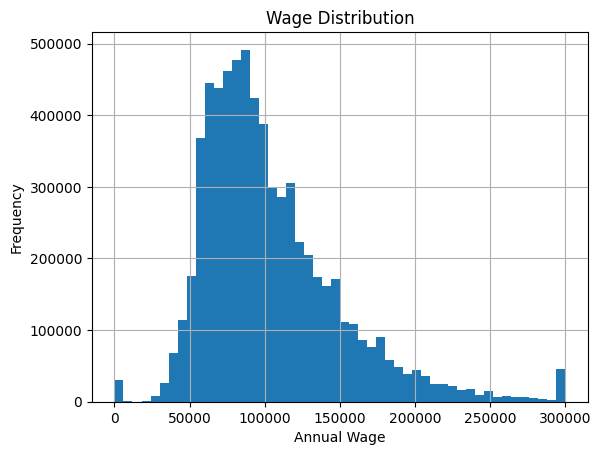

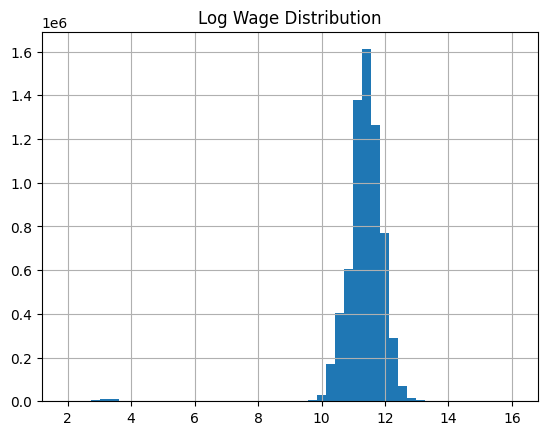

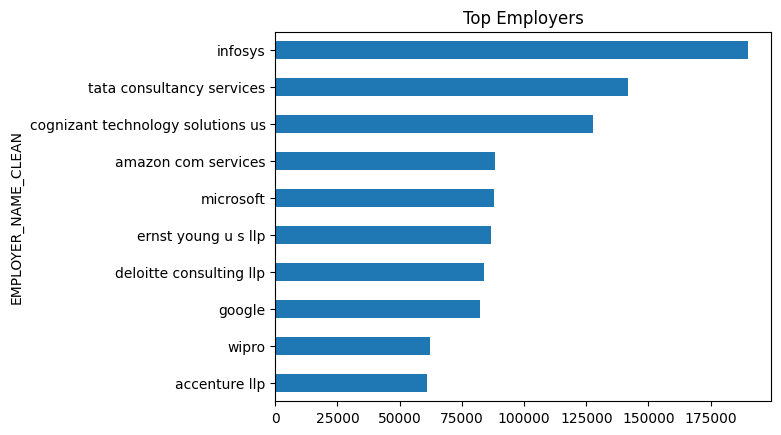

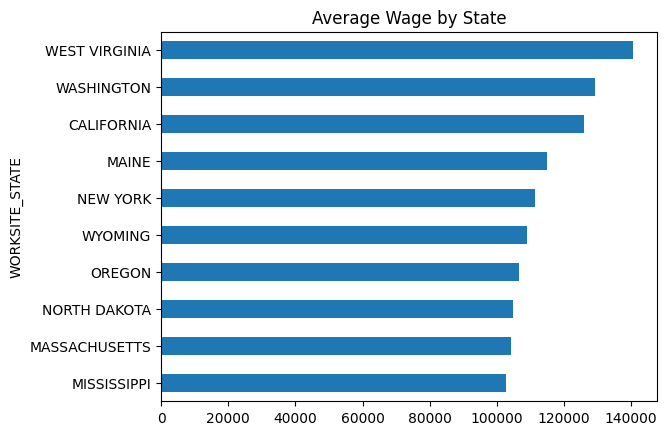

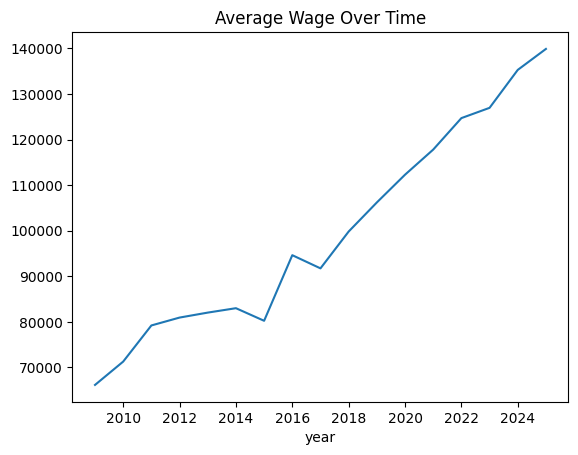

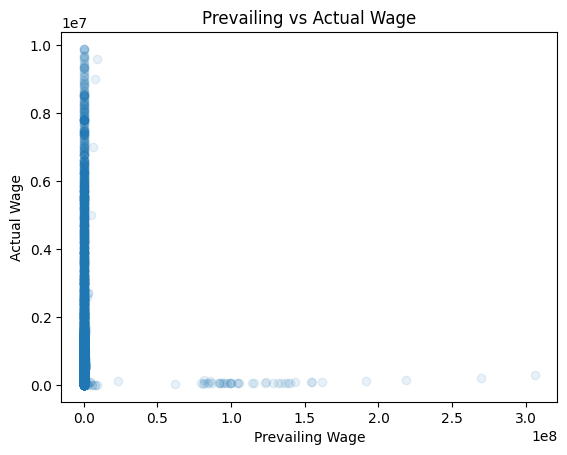

,count,mean,std,median
WORKSITE_STATE,,,,
MARSHALL ISLANDS,1,1.03,NaN,1.03
GU,5201,1.09,0.98,1.02
PW,7,1.11,0.15,1.06
GUAM,287,1.12,0.66,1.02
NEW JERSEY,409555,1.13,0.67,1.06
FM,1,1.14,NaN,1.14
MH,4,1.15,0.03,1.15
VIRGINIA,190443,1.15,0.68,1.06
AS,3,1.16,0.21,1.08


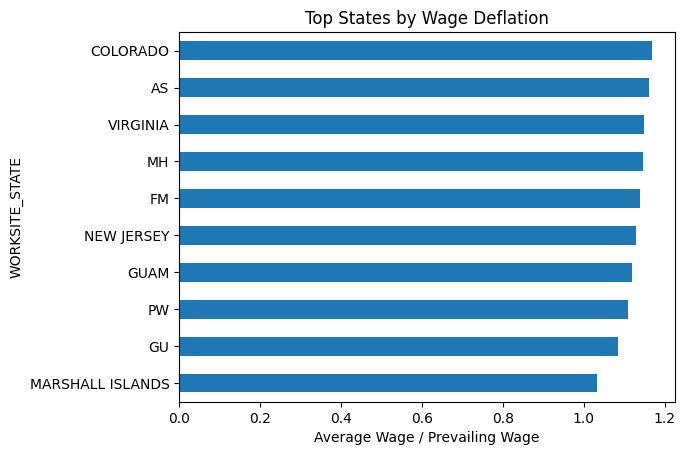

,count,mean,std,median
EMPLOYER_NAME_CLEAN,,,,
cognizant technology solutions us,127542,1.02,0.18,1.00
wipro,62187,1.04,0.34,1.00
tech mahindra americas,37906,1.05,0.19,1.00
capgemini america,46252,1.09,0.48,1.01
ibm india private,32873,1.11,0.32,1.09
infosys,189873,1.11,0.18,1.08
hcl america,48835,1.13,0.19,1.10
larsen toubro infotech,27357,1.19,0.59,1.13
jpmorgan chase,28941,1.20,0.29,1.14


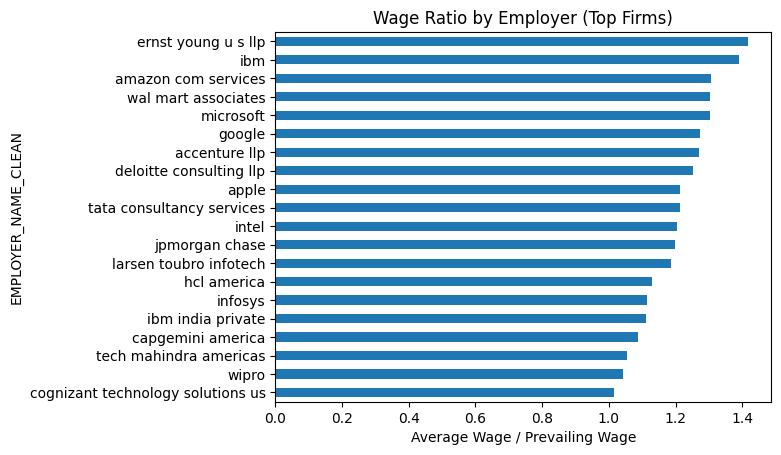

,WORKSITE_STATE,EMPLOYER_NAME_CLEAN,wage_ratio
41,ALABAMA,accenture llp,1.26
188,ALABAMA,amazon com services,1.17
521,ALABAMA,capgemini america,1.13
642,ALABAMA,cognizant technology solutions us,1.02
826,ALABAMA,deloitte consulting llp,1.36


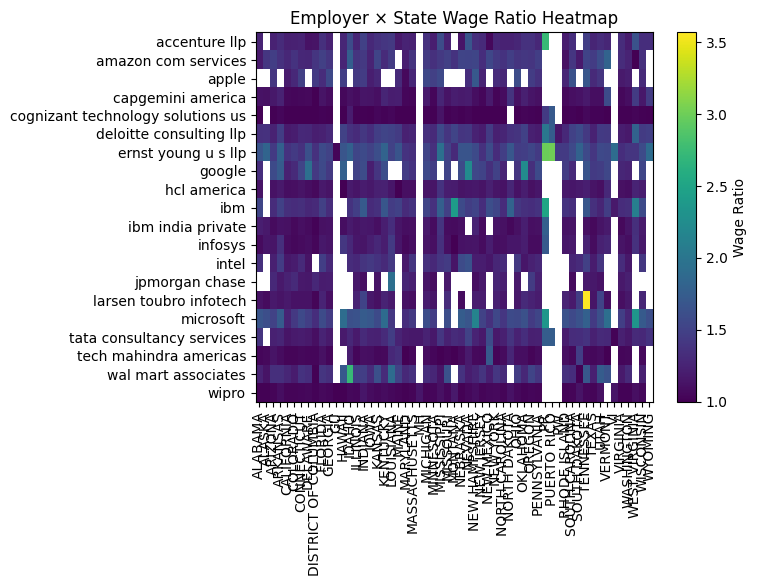

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

#DATA SUMMARY STATISTICS


df = pd.read_parquet("../data/final_cleaned.parquet")
pd.options.display.float_format = '{:,.0f}'.format

print("Total shape:", df.shape)
by_year = (
    df.groupby('year')['WAGE_RATE_OF_PAY']
    .agg(['count', 'mean', 'std', 'median'])
    .sort_index()
)
top_employers = df['EMPLOYER_NAME_CLEAN'].value_counts().head(10).index
by_employer = (
    df[df['EMPLOYER_NAME_CLEAN'].isin(top_employers)]
    .groupby('EMPLOYER_NAME_CLEAN')['WAGE_RATE_OF_PAY']
    .agg(['count', 'mean', 'std', 'median'])
    .sort_values('count', ascending=False)
)
by_state = (
    df.groupby('WORKSITE_STATE')['WAGE_RATE_OF_PAY']
    .agg(['count', 'mean', 'std', 'median'])
    .sort_values('count', ascending=False)
)

# round everything nicely
by_year_fmt = by_year.round(2)
by_employer_fmt = by_employer.round(2)
by_state_fmt = by_state.round(2)

print("📊 Summary of Wage by Year")
display(by_year_fmt)

print("🏢 Summary of Wage by Top Employers")
display(by_employer_fmt)

print("🌎 Summary by State")
display(by_state_fmt.head(15))

plt.figure()
df['WAGE_RATE_OF_PAY'].clip(upper=300000).hist(bins=50)
plt.title("Wage Distribution")
plt.xlabel("Annual Wage")
plt.ylabel("Frequency")
plt.show()

plt.figure()
df['log_wage'].hist(bins=50)
plt.title("Log Wage Distribution")
plt.show()

top_emp = df['EMPLOYER_NAME_CLEAN'].value_counts().head(10)

plt.figure()
top_emp.sort_values().plot(kind='barh')
plt.title("Top Employers")
plt.show()

state_wage = df.groupby('WORKSITE_STATE')['WAGE_RATE_OF_PAY'].mean().sort_values(ascending=False).head(10)

plt.figure()
state_wage.sort_values().plot(kind='barh')
plt.title("Average Wage by State")
plt.show()

trend = df.groupby('year')['WAGE_RATE_OF_PAY'].mean()

plt.figure()
trend.plot()
plt.title("Average Wage Over Time")
plt.show()

plt.figure()
plt.scatter(df['PREVAILING_WAGE'], df['WAGE_RATE_OF_PAY'], alpha=0.1)
plt.xlabel("Prevailing Wage")
plt.ylabel("Actual Wage")
plt.title("Prevailing vs Actual Wage")
plt.show()

pd.options.display.float_format = '{:,.2f}'.format

state_ratio = (
    df.groupby('WORKSITE_STATE')['wage_ratio']
    .agg(['count', 'mean', 'std', 'median'])
    .sort_values('mean', ascending=True)
)

display(state_ratio.head(15))

top_states = state_ratio.head(10)

plt.figure()
top_states['mean'].sort_values(ascending=True).plot(kind='barh')
plt.title("Top States by Wage Deflation")
plt.xlabel("Average Wage / Prevailing Wage")
plt.show()

top_emp = df['EMPLOYER_NAME_CLEAN'].value_counts().head(20).index

emp_ratio = (
    df[df['EMPLOYER_NAME_CLEAN'].isin(top_emp)]
    .groupby('EMPLOYER_NAME_CLEAN')['wage_ratio']
    .agg(['count', 'mean', 'std', 'median'])
    .sort_values('mean', ascending=True)
)

display(emp_ratio)

plt.figure()
emp_ratio['mean'].sort_values(ascending=True).plot(kind='barh')
plt.title("Wage Ratio by Employer (Top Firms)")
plt.xlabel("Average Wage / Prevailing Wage")
plt.show()

combo = (
    df.groupby(['WORKSITE_STATE', 'EMPLOYER_NAME_CLEAN'])['wage_ratio']
    .mean()
    .reset_index()
)

# focus on big employers only
combo = combo[combo['EMPLOYER_NAME_CLEAN'].isin(top_emp)]

display(combo.head())

pivot = combo.pivot(index='EMPLOYER_NAME_CLEAN', columns='WORKSITE_STATE', values='wage_ratio')

plt.figure()
plt.imshow(pivot, aspect='auto')
plt.colorbar(label='Wage Ratio')
plt.title("Employer × State Wage Ratio Heatmap")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=90)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.show()


Underpayment rate: 0.004672491977185495


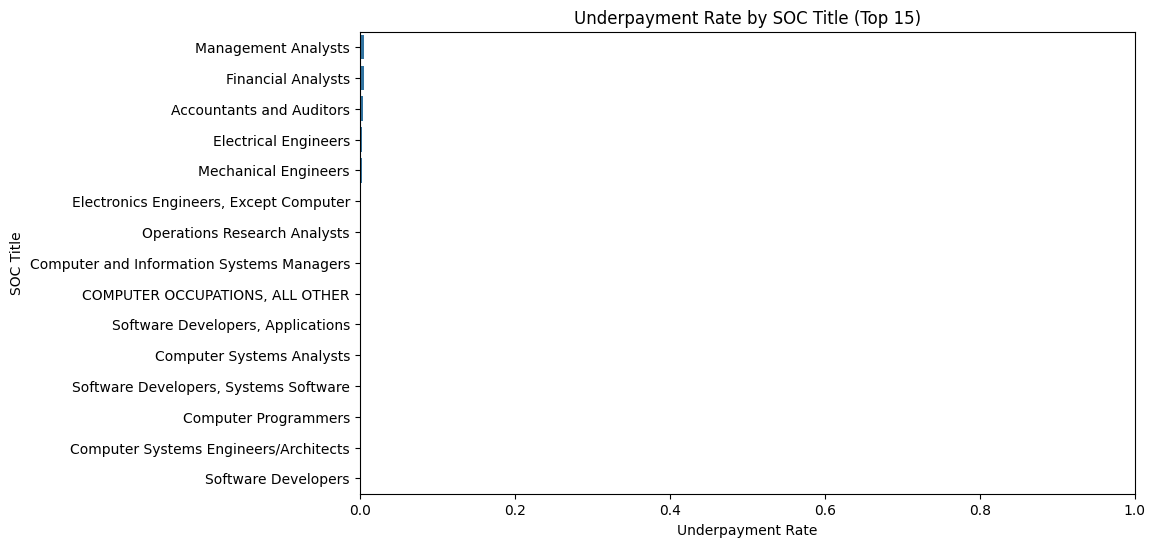

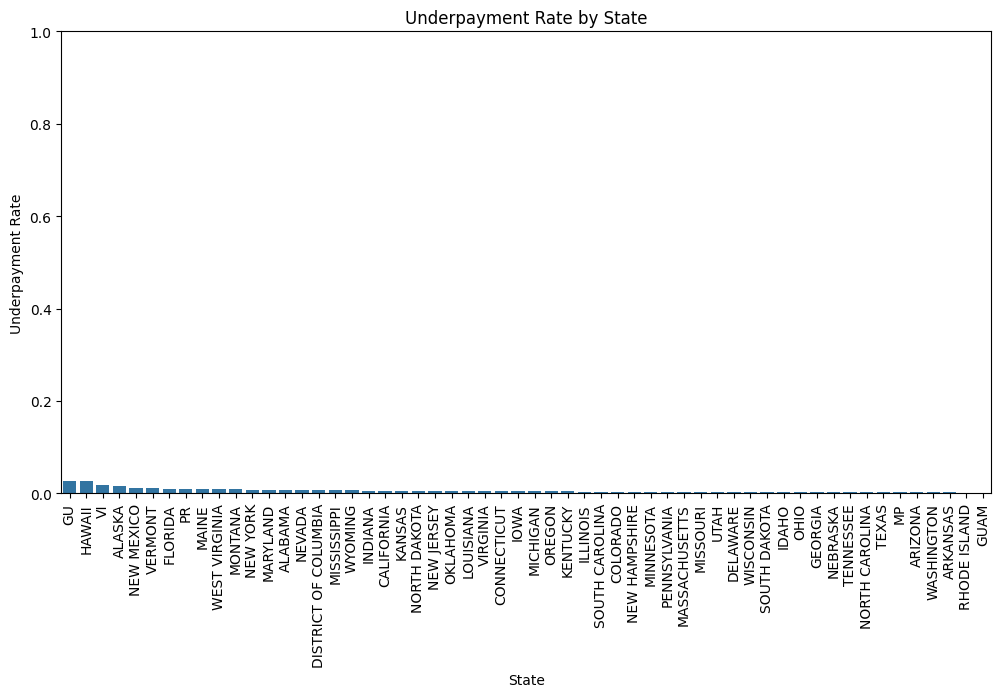

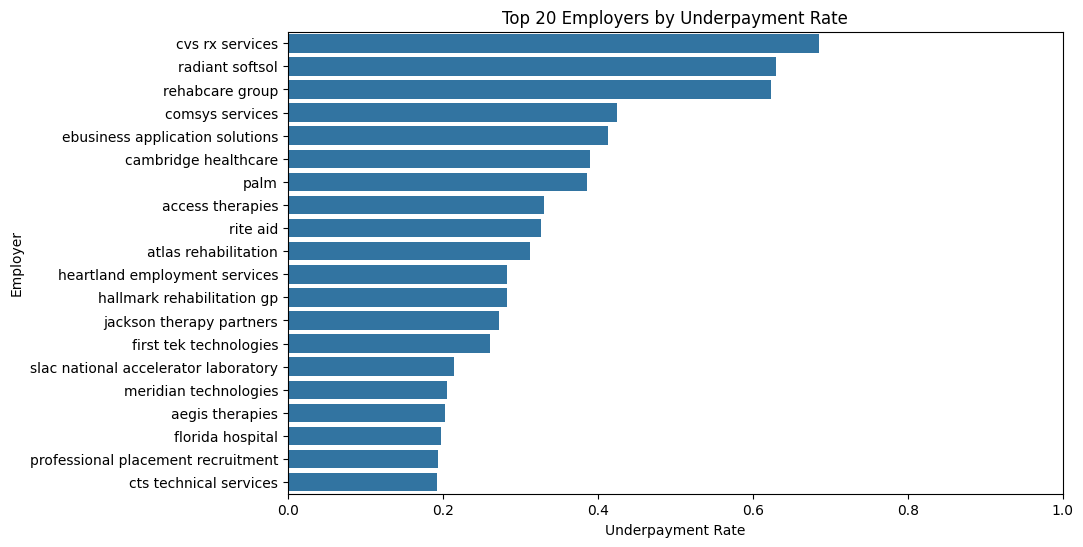

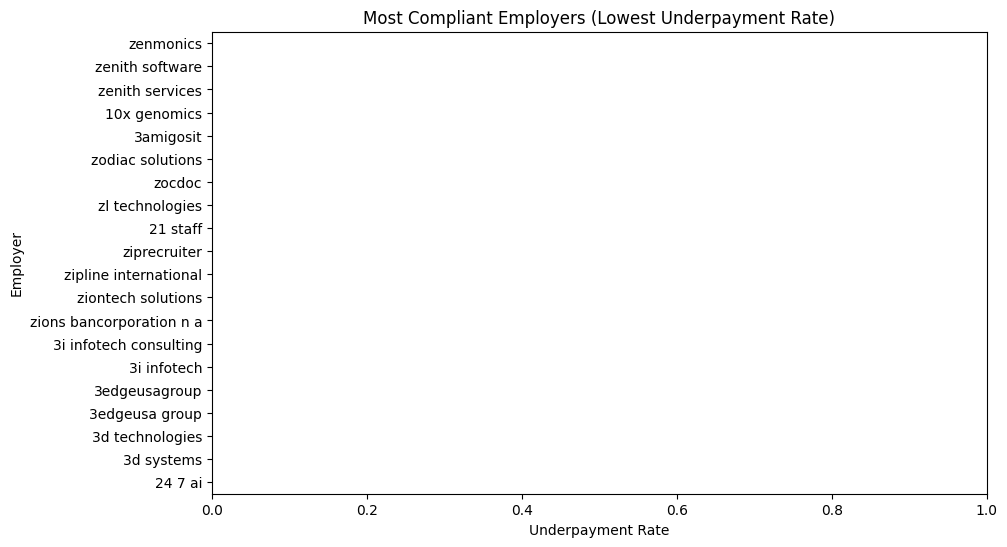

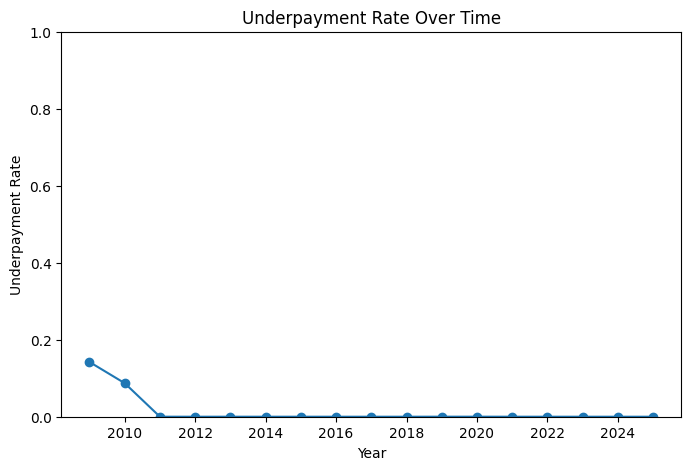

In [2]:
#DIGGING INTO WAGE GAP
import seaborn as sns

print("Underpayment rate:", (df["wage_ratio"] < 1).mean())

df['underpaid']=(df["wage_ratio"]<1).astype(int)
df["SOC_CODE"] = (
    df["SOC_CODE"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.00$", "", regex=True)  # remove trailing .00 only
)

soc_title_map = (
    df
    .groupby(["SOC_CODE", "SOC_TITLE"])  # change SOC_NAME if needed
    .size()
    .reset_index(name="count")
    .sort_values(["SOC_CODE", "count"], ascending=[True, False])
    .drop_duplicates("SOC_CODE")
    .set_index("SOC_CODE")["SOC_TITLE"]
)

df["SOC_TITLE_CLEAN"] = df["SOC_CODE"].map(soc_title_map)

top_soc = df["SOC_CODE"].value_counts().head(15).index
df_soc = df[df["SOC_CODE"].isin(top_soc)]

soc_rates = (
    df_soc
    .groupby("SOC_TITLE_CLEAN")
    .agg(
        underpay_rate=("underpaid", "mean"),
        n=("underpaid", "size")
    )
    .sort_values("underpay_rate", ascending=False)
)

plt.figure(figsize=(10,6))
sns.barplot(
    x=soc_rates["underpay_rate"],
    y=soc_rates.index
)

plt.title("Underpayment Rate by SOC Title (Top 15)")
plt.xlabel("Underpayment Rate")
plt.ylabel("SOC Title")

plt.xlim(0, 1)
plt.show()

state_counts = df["WORKSITE_STATE"].value_counts()
valid_states = state_counts[state_counts >= 100].index

df_state = df[df["WORKSITE_STATE"].isin(valid_states)]

state_rates = (
    df_state
    .groupby("WORKSITE_STATE")
    .agg(
        underpay_rate=("underpaid", "mean"),
        n=("underpaid", "size")
    )
    .sort_values("underpay_rate", ascending=False)
)

plt.figure(figsize=(12,6))
sns.barplot(
    x=state_rates.index,
    y=state_rates["underpay_rate"]
)

plt.xticks(rotation=90)
plt.title("Underpayment Rate by State")
plt.ylabel("Underpayment Rate")
plt.xlabel("State")

plt.ylim(0, 1)
plt.show()

emp_counts = df["EMPLOYER_NAME_CLEAN"].value_counts()
top_employers = emp_counts[emp_counts >= 100].index  # adjust threshold

df_emp = df[df["EMPLOYER_NAME_CLEAN"].isin(top_employers)]

emp_rates = (
    df_emp
    .groupby("EMPLOYER_NAME_CLEAN")
    .agg(
        underpay_rate=("underpaid", "mean"),
        n=("underpaid", "size")
    )
    .sort_values("underpay_rate", ascending=False)
)

top20 = emp_rates.head(20)

plt.figure(figsize=(10,6))
sns.barplot(
    x=top20["underpay_rate"],
    y=top20.index
)

plt.title("Top 20 Employers by Underpayment Rate")
plt.xlabel("Underpayment Rate")
plt.ylabel("Employer")

plt.xlim(0, 1)
plt.show()

bottom20 = emp_rates.tail(20)

plt.figure(figsize=(10,6))
sns.barplot(
    x=bottom20["underpay_rate"],
    y=bottom20.index
)

plt.title("Most Compliant Employers (Lowest Underpayment Rate)")
plt.xlabel("Underpayment Rate")
plt.ylabel("Employer")

plt.xlim(0, 1)
plt.show()

year_rates = (
    df.groupby("year")
    .agg(
        underpay_rate=("underpaid", "mean"),
        n=("underpaid", "size")
    )
    .sort_index()
)

plt.figure(figsize=(8,5))
plt.plot(year_rates.index, year_rates["underpay_rate"], marker="o")
plt.title("Underpayment Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Underpayment Rate")
plt.ylim(0, 1)
plt.show()

#Almost all wage ratios are >1 since it was an automated system to reject any application with suggested wage < prevailing wage. So we will not 
#detect underpayment directly from reported wage ratio.
#However, underpayment could come from underreporting wage level

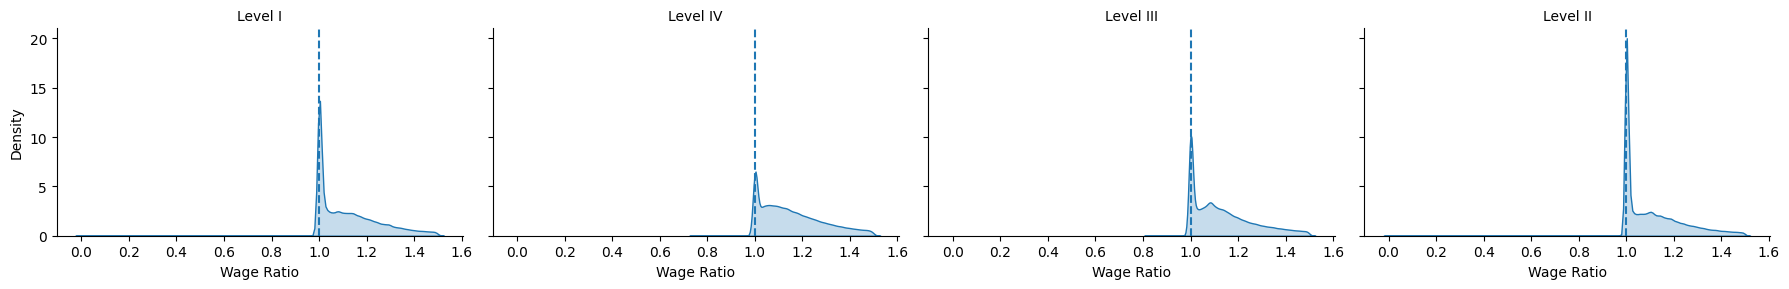

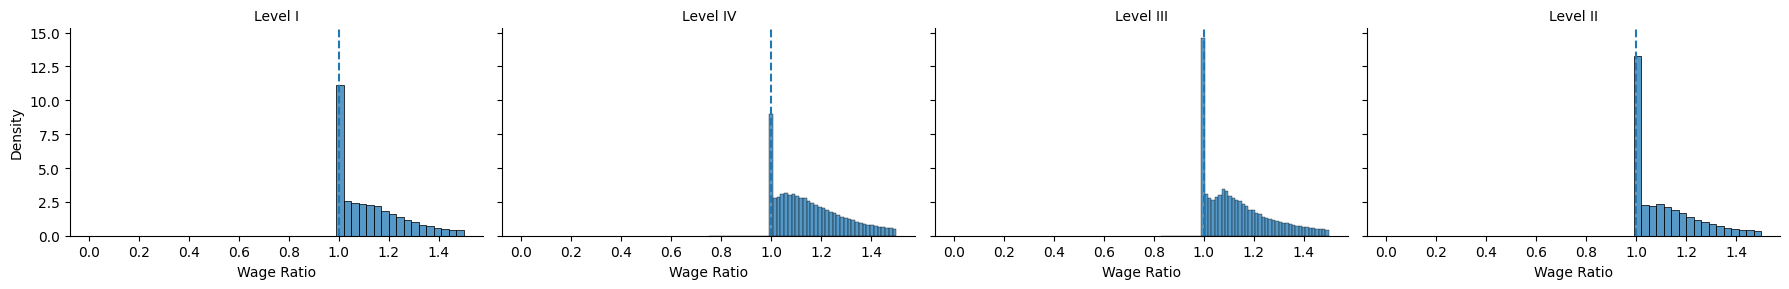

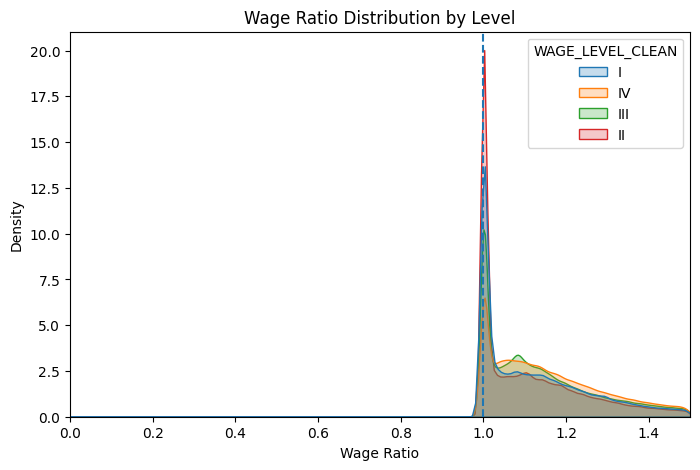

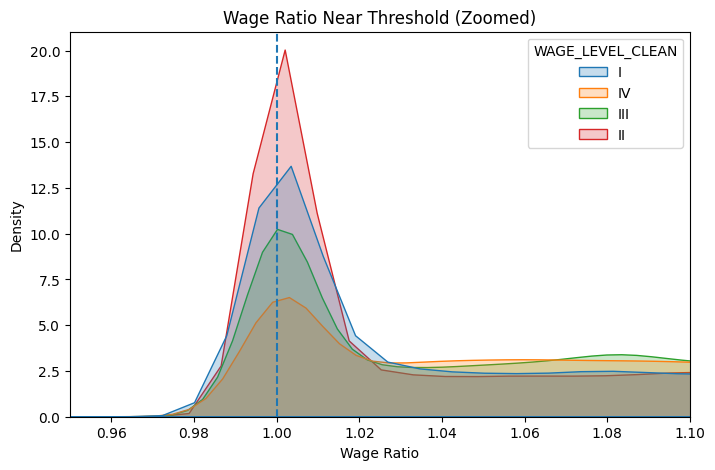

In [3]:
#Analyzing wage-level bunching and distributions

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df_plot = df.copy()

# Keep valid wage levels
df_plot = df_plot[df_plot["WAGE_LEVEL_CLEAN"].isin(["I", "II", "III", "IV"])]

# Remove extreme / faulty values
df_plot = df_plot[df_plot["wage_ratio"] < 1.5]

# --- KDE FACET PLOT ---
g = sns.FacetGrid(
    df_plot,
    col="WAGE_LEVEL_CLEAN",
    sharex=True,
    sharey=True,
    height=3,
    aspect=1.5
)

g.map(sns.kdeplot, "wage_ratio", fill=True)

# Add vertical line at 1 (compliance threshold)
for ax in g.axes.flat:
    ax.axvline(1, linestyle="--")

g.set_axis_labels("Wage Ratio", "Density")
g.set_titles(col_template="Level {col_name}")

plt.tight_layout()
plt.show()


# --- HISTOGRAM FACET PLOT ---
g = sns.FacetGrid(
    df_plot,
    col="WAGE_LEVEL_CLEAN",
    sharex=True,
    sharey=True,
    height=3,
    aspect=1.5
)

g.map(
    sns.histplot,
    "wage_ratio",
    bins=50,
    stat="density"
)

for ax in g.axes.flat:
    ax.axvline(1, linestyle="--")

g.set_axis_labels("Wage Ratio", "Density")
g.set_titles(col_template="Level {col_name}")

plt.tight_layout()
plt.show()


# --- OVERLAY KDE (ALL LEVELS) ---
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df_plot,
    x="wage_ratio",
    hue="WAGE_LEVEL_CLEAN",
    fill=True,
    common_norm=False
)

plt.axvline(1, linestyle="--")
plt.title("Wage Ratio Distribution by Level")
plt.xlabel("Wage Ratio")
plt.ylabel("Density")
plt.xlim(0, 1.5)

plt.show()


# --- ZOOMED-IN VIEW NEAR THRESHOLD ---
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df_plot,
    x="wage_ratio",
    hue="WAGE_LEVEL_CLEAN",
    fill=True,
    common_norm=False
)

plt.axvline(1, linestyle="--")
plt.xlim(0.95, 1.1)

plt.title("Wage Ratio Near Threshold (Zoomed)")
plt.xlabel("Wage Ratio")
plt.ylabel("Density")

plt.show()

#We see that there is a significant spike around wage ratio 1 at all four levels, however this is most extreme at levels 1 and 2.
#This indicates that following the automatic denial regulatory change, employers are largely just bunching their proposed salaries at the minimum.

                                near_rate    n
EMPLOYER_NAME_CLEAN                           
ultimus solutions                    1.00  117
emc consulting group                 1.00  235
renowned                             1.00  196
upstate cerebral palsy               1.00  224
ispero                               1.00  121
primitive partners                   1.00  139
bridge group                         1.00  182
vaakruthi solutions                  1.00  109
eguru solution                       1.00  144
data boss international              1.00  128
nyc hhc harlem hospital center       1.00  101
hanu technologies                    1.00  181
skillgigs                            1.00  112
u s interactive delaware             1.00  134
u s hi tech solutions                1.00  105
jobs n profiles                      1.00  146
amicus global it                     1.00  203
datastack technologies               1.00  120
health carousel ii                   1.00  275
nitya softwar

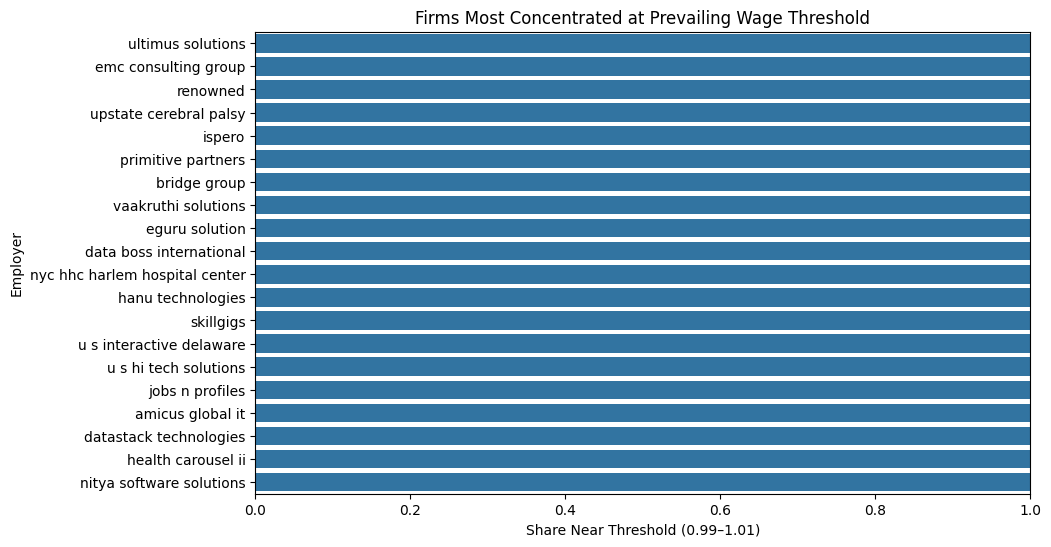

In [4]:
#By-employer: are certain companies consistently close to the cutoff?

df["near_threshold"] = df["wage_ratio"].between(0.99, 1.05)

firm_stats = (
    df.groupby("EMPLOYER_NAME_CLEAN")
    .agg(
        near_rate=("near_threshold", "mean"),
        n=("near_threshold", "size")
    )
)

firm_stats = firm_stats[firm_stats["n"] >= 100]  

top_firms = firm_stats.sort_values("near_rate", ascending=False).head(20)
print(top_firms)

bottom_firms = firm_stats.sort_values("near_rate", ascending=True).head(20)
print(bottom_firms)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_firms["near_rate"],
    y=top_firms.index
)

plt.xlabel("Share Near Threshold (0.99–1.01)")
plt.ylabel("Employer")
plt.title("Firms Most Concentrated at Prevailing Wage Threshold")

plt.xlim(0, 1)
plt.show()

In [ ]:
#Could firms be manipulating their wage level selections? Look for firms with high wage level 1, 2 proportions and wages near the cutoff

# --- PARAMETERS ---
MIN_N = 100              # minimum filings per employer
NEAR_LOW = 0.99          # threshold band
NEAR_HIGH = 1.05
POST_2019_ONLY = False    # set False if you want all years

# --- PREP ---
df_work = df.copy()

if POST_2019_ONLY:
    df_work = df_work[df_work["year"] >= 2019]

# ensure clean wage level
df_work = df_work[df_work["WAGE_LEVEL_CLEAN"].isin(["I", "II", "III", "IV"])]

# define near-threshold indicator
df_work["near_threshold"] = df_work["wage_ratio"].between(NEAR_LOW, NEAR_HIGH)

# --- EMPLOYER SUMMARY ---
emp_summary = (
    df_work.groupby("EMPLOYER_NAME_CLEAN")
    .agg(
        n=("wage_ratio", "size"),
        level1_share=("WAGE_LEVEL_CLEAN", lambda x: (x == "I").mean()),
        level2_share=("WAGE_LEVEL_CLEAN", lambda x: (x == "II").mean()),
        level3_share=("WAGE_LEVEL_CLEAN", lambda x: (x == "III").mean()),
        level4_share=("WAGE_LEVEL_CLEAN", lambda x: (x == "IV").mean()),
        near_rate=("near_threshold", "mean"),
        avg_ratio=("wage_ratio", "mean")
    )
)

# filter to sufficiently large employers
emp_summary = emp_summary[emp_summary["n"] >= MIN_N]

# --- BUILD SUSPICION SCORE ---
# emphasize: heavy use of low levels + strong bunching
emp_summary["low_level_share"] = (
    emp_summary["level1_share"] + emp_summary["level2_share"]
)

emp_summary["suspicion_score"] = (
    0.5 * emp_summary["low_level_share"] +
    0.5 * emp_summary["near_rate"]
)

# --- RANK EMPLOYERS ---
suspicious_employers = emp_summary.sort_values(
    "suspicion_score", ascending=False
)

# --- OUTPUT TOP RESULTS ---
top_suspicious = suspicious_employers.head(20)

print(top_suspicious)